
# Technical AI Workshop – Session 2  
## Supervised Document Classification

In this notebook, we explore **how a computer can learn which words are important** for classifying documents into topics like **sports, medicine, and technology**.  

We will use **Logistic Regression with L1 regularization**. The model will:
- Automatically **pick meaningful words** and ignore noisy ones.
- Allow us to see which words the model deems important.
- Show how learning shapes the similarity between documents.


In [ ]:

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Load a small subset of 20 newsgroups
categories = ['comp.windows.x', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.med']
newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42,
                                remove=('headers','footers','quotes'),
                                categories=categories)
df = pd.DataFrame({"text": newsgroups.data, "target": newsgroups.target})
target_names = newsgroups.target_names

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)


# We sort to make patterns understandable in the heatmaps
sorted_indices_train = np.argsort(y_train)
sorted_indices_test = np.argsort(y_test)
X_train= X_train.iloc[sorted_indices_train].reset_index(drop=True)
X_test= X_test.iloc[sorted_indices_test].reset_index(drop=True)  
y_train = y_train.iloc[sorted_indices_train].reset_index(drop=True)
y_test = y_test.iloc[sorted_indices_test].reset_index(drop=True)



### Step 1: Train Logistic Regression with L1

We use **L1 regularization** (also called Lasso) to **force many coefficients to zero**, effectively letting the model **forget irrelevant words**.  

Words with nonzero coefficients are those the model thinks are meaningful for distinguishing topics.


## How the Model Works

We use a **pipeline** with two steps (like a recipe):

- **Step 1 (TF-IDF):** Turn text → numbers  
  (important words get higher values)

- **Step 2 (Classifier):** Use those numbers to decide:  
  *“Is this sports, medicine, or tech?”*

---

## Step 1: Representing Text (TF-IDF)

We cannot work with raw text directly, so we convert each document into numbers.

> “We turn each document into a long list of numbers, where each position corresponds to a word.”

- **Vocabulary = dimensions** (one dimension per word)
- **TF-IDF = importance score** (how important a word is in a document)
- **Sparse vectors:** most entries are zero (because most words don’t appear in a document)

---

## Step 2: Classification (Linear Model)

The classifier is a **linear model**. It works like this:

> Each word gives a “vote” for a category, and the model adds up all the votes.

- Words like *“baseball”* push toward **sports**
- Words like *“doctor”* push toward **medicine**
- Words like *“windows”* push toward **technology**

The model picks the category with the strongest total score.

---

## L1 Regularization (penalty='l1')

We tell the model to be **picky about words**:

> “Only keep a small number of important words. Ignore the rest.”

- Many word weights become **zero**
- Only the most useful words remain
- This makes the model easier to understand

In [10]:

# Pipeline: TF-IDF -> Logistic Regression with L1
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.8)),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr'))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {accuracy:.3f}")
print(metrics.classification_report(y_test, y_pred, target_names=target_names))


Accuracy on test set: 0.867
                    precision    recall  f1-score   support

    comp.windows.x       0.97      0.88      0.92       198
rec.sport.baseball       0.89      0.79      0.84       199
  rec.sport.hockey       0.96      0.83      0.89       200
           sci.med       0.72      0.96      0.83       198

          accuracy                           0.87       795
         macro avg       0.88      0.87      0.87       795
      weighted avg       0.88      0.87      0.87       795



/opt/miniconda3/envs/ML/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/envs/ML/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



### Step 2: See Which Words the Model Selected

We examine **nonzero coefficients** to see the words that the model kept.  
This is like a **feature mask**: the model turns off unhelpful words and keeps the ones that carry real signal.


In [12]:

# Get feature names and coefficients
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients = pipeline.named_steps['clf'].coef_

# Identify nonzero coefficients
non_zero_indices = np.where(coefficients != 0)
important_features = np.unique(feature_names[non_zero_indices[1]])

print(f"Original number of features: {len(feature_names)}")
print(f"Number of features kept by L1: {len(important_features)}")
print("Sample of important features:", important_features)


Original number of features: 33129
Number of features kept by L1: 324
Sample of important features: ['00' '000' '03' '11' '25' '55' 'aaa' 'abc' 'aix' 'al' 'allergy' 'alomar'
 'application' 'april' 'ball' 'banks' 'baseball' 'baseman' 'bat' 'batting'
 'bb' 'beat' 'better' 'blood' 'blues' 'body' 'bonds' 'bone' 'braves'
 'bruins' 'buffalo' 'bullpen' 'button' 'canada' 'cancer' 'candida' 'caps'
 'captain' 'care' 'career' 'case' 'catcher' 'cause' 'cherry' 'chi'
 'chronic' 'clemens' 'cleveland' 'clients' 'clint' 'coach' 'code' 'color'
 'com' 'comp' 'compile' 'copy' 'corn' 'cubs' 'cup' 'dave' 'day' 'deal'
 'defensive' 'det' 'detroit' 'devils' 'diet' 'dino' 'disease' 'display'
 'dl' 'doctor' 'does' 'don' 'drug' 'drugs' 'ear' 'eat' 'effect' 'effects'
 'email' 'era' 'erickson' 'espn' 'evidence' 'experience' 'eye' 'fan' 'fat'
 'fever' 'field' 'file' 'finland' 'flames' 'flyers' 'font' 'food' 'friend'
 'ftp' 'fuhr' 'function' 'game' 'games' 'gant' 'geb' 'giants' 'gilmour'
 'gm' 'goal' 'goalie' 'goals


### Step 3: Visualize Document Similarity

We can **compare cosine similarity between documents** before and after L1 filtering.  
This shows how the model’s feature selection changes the representation:
- Documents are more clearly grouped by topic after removing noisy words.


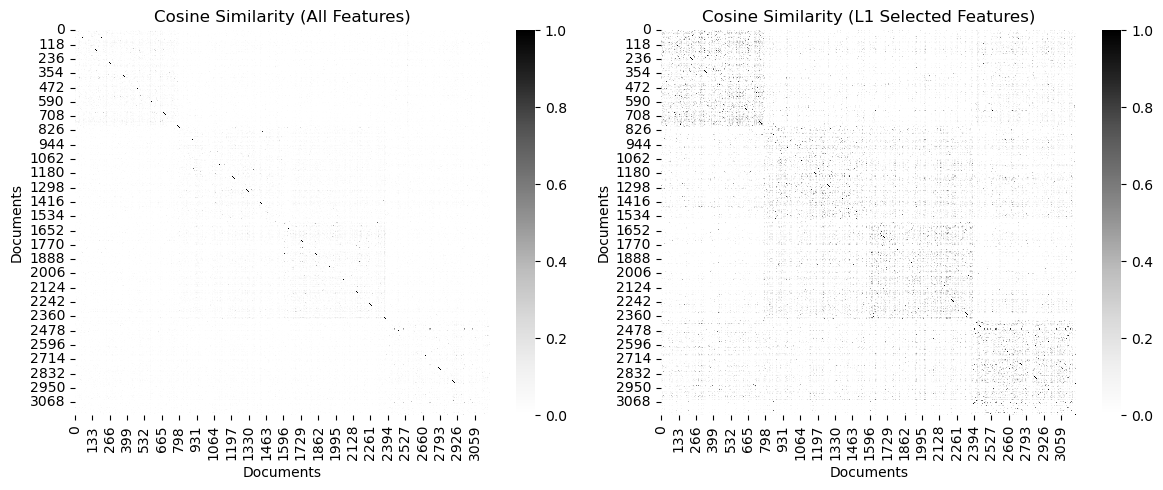

In [13]:

# Cosine similarity before filtering
vectorizer_full = pipeline.named_steps['tfidf']
X_full = vectorizer_full.transform(X_train)
cos_full = cosine_similarity(X_full)

# Cosine similarity after keeping only important features
vectorizer_l1 = TfidfVectorizer(stop_words='english', vocabulary=important_features)
X_l1 = vectorizer_l1.fit_transform(X_train)
cos_l1 = cosine_similarity(X_l1)

# Plot side by side
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cos_full, cmap='Greys', vmin=0, vmax=1)
plt.title("Cosine Similarity (All Features)")
plt.xlabel("Documents")
plt.ylabel("Documents")

plt.subplot(1,2,2)
sns.heatmap(cos_l1, cmap='Greys', vmin=0, vmax=1)
plt.title("Cosine Similarity (L1 Selected Features)")
plt.xlabel("Documents")
plt.ylabel("Documents")

plt.tight_layout()
plt.show()


# now we make a heatmap of the confusion matrix

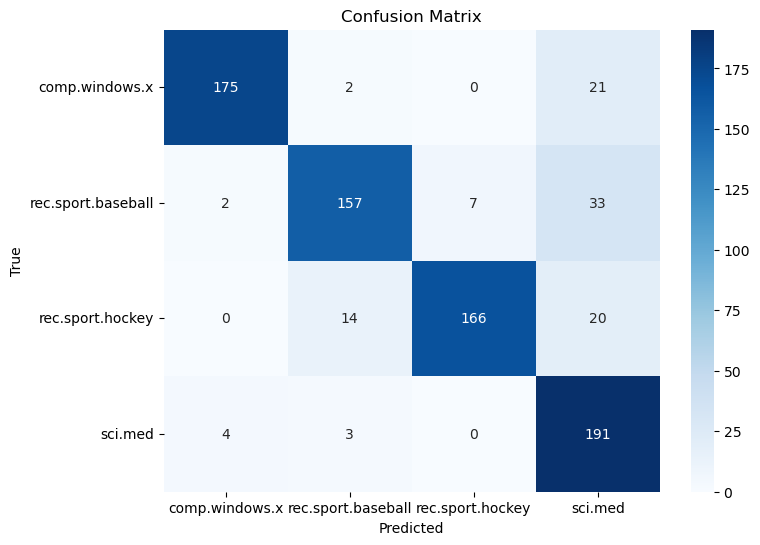

In [14]:
# confusion matrix heatmap
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show() 

## 🔍 What to Observe

### Representation (TF-IDF)
- Inspect a document vector: most entries are zero.
- Only a small subset of words has nonzero values.
- These values reflect how important a word is within the document and across documents.

---

### Classification (Linear Model)
- Each class has its own set of word weights.
- Positive weights push a document toward a class.
- Negative weights push it away.
- The final prediction is based on the total score across all words.

---

### L1 Regularization (Feature Selection)
- Compare:
  - Total number of words (features)
  - Number of words kept after L1
- Many coefficients become exactly zero.
- Remaining words define the model’s decision.

---

### Important Words
- Look at the selected features:
  - Do they clearly relate to their topics?
  - Are there any surprising words?
- These words are the model’s “compressed understanding” of each class.

---

### Similarity (Before vs After L1)
- Compare the two heatmaps:
  - Before L1: more noise, less structure
  - After L1: clearer block patterns
- Documents from the same class become more similar after filtering.

---

### Confusion Matrix
- Diagonal = correct predictions
- Off-diagonal = mistakes
- Identify:
  - Which classes are confused with each other
  - Whether errors make intuitive sense


### Summary

- **Representation:** TF-IDF transforms raw text into numerical vectors.  
- **Learning & Feature Selection:** Logistic Regression with L1 automatically **forgets noisy words** and keeps meaningful ones.  
- **Effect on similarity:** Cosine similarity after L1 shows **clearer topic clusters**, highlighting how learning reshapes the representation.  

This notebook demonstrates **how supervised learning can discover meaningful structure in text**, without manually specifying which words matter.
